<a href="https://colab.research.google.com/github/dz-web3/DS-Tech-2026spring/blob/main/Homework/HW_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#If opening in colab run this cell
!git clone https://github.com/dz-web3/DS-Tech-2026spring.git
%cd DS-Tech-2026spring/Homework/

# IF OPENING IN COLAB, REMEMBER TO SAVE THIS NOTEBOOK TO GOOGLE DRIVE!

# Predicting Churn

After discussing the churn problem at TelCo with Henrietta for a while (remember, from your pre-class assignment?), you've finally defined an adequate target variable for churn and gathered relevant data to predict it. Moreover, the marketing department has come up with an amazing retention offer: the offer is guaranteed to convince customers to extend their contract for an extra year after receiving it. Unfortunately, the offer is quite expensive; it costs $200. You've been authorized to give the retention offer to up to 25% of the customers whose contracts are expiring.

It is your job to use data from previous contract expirations to build a churn predictive model and make a recommendation of whom to target with the offers. You have assembled the best historical data set you can at this point, which includes:

- Gender: Whether the customer is a male or a female
- SeniorCitizen: Whether the customer is a senior citizen or not (1, 0)
- Partner: Whether the customer has a partner or not (Yes, No)
- Dependents: Whether the customer has dependents or not (Yes, No)
- tenure: Number of months the customer has stayed with the company
- PhoneService: Whether the customer has a phone service or not (Yes, No)
- MultipleLines: Whether the customer has multiple lines or not (Yes, No, No phone service)
- InternetService: Customer’s internet service provider (DSL, Fiber optic, No)
- OnlineSecurity: Whether the customer has online security or not (Yes, No, No internet service)
- OnlineBackup: Whether the customer has online backup or not (Yes, No, No internet service)
- DeviceProtection: Whether the customer has device protection or not (Yes, No, No internet service)
- TechSupport: Whether the customer has tech support or not (Yes, No, No internet service)
- StreamingTV: Whether the customer has streaming TV or not (Yes, No, No internet service)
- StreamingMovies: Whether the customer has streaming movies or not (Yes, No, No internet service)
- Contract: The contract term of the customer (Month-to-month, One year, Two year)
- PaperlessBilling: Whether the customer has paperless billing or not (Yes, No)
- PaymentMethod: The customer’s payment method (Electronic check, Mailed check, Bank transfer (automatic), Credit card (automatic))
- MonthlyCharges: The amount charged to the customer monthly
- Churn: Whether the customer churned or not shortly after contract expiration (Yes or No)

__1. Load the churn data. The code below will also transform your categorical variables into dummy variables. No points for this. This is just meant to help you get started.__

In [1]:
import numpy as np
import pandas as pd

# If necessary change the path below so that it points to your file.
data_path = "./data/data-hw3.csv"

df = pd.read_csv(data_path)
df = pd.get_dummies(df, drop_first=True)

__2. Split the data into 80% training data and 20% test data.__

In [2]:
# Your code goes here
from sklearn.model_selection import train_test_split

target = "Churn_Yes"
predictors = df.columns[df.columns != target]

X = df[predictors]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

__3. Build the best model you can for each of the following three model types:__
- __A decision tree classifier. Try different values for the hyperparameter min_samples_leaf.__
- __A logistic regression. Try different values for the hyperparameter C.__
- __A third model of your choice. Some suggestions: RandomForest, KNN, SVM, etc. Try different hyperparamater values for this one too.__

_Try to optimize generalization performance, evaluated based on ROC Area and cross-validation with 10 folds. Remember to use only the training data (do not use the test data at all for this part). For each of these model types, you should report the best hyperparameter value you found and the corresponding ROC Area from the cross-validation. Your code should also show the process you went through to try different complexity parameter(s) for each model type. Pick one model to move forward with. Why did you select this one?__

__HINT: There is an example below of the ROC Area for a DecisionTreeClassifier using cross validation.__  

In [3]:
# The code below is just meant as an example of computing an ROC Area using cross validation.

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score

target = "Churn_Yes"
predictors = df.columns[df.columns != target]
example_model = DecisionTreeClassifier()
# Remember to only use the training data here!!
avg_auc = cross_val_score(example_model, X_train, y_train, cv=10, scoring="roc_auc").mean()
print(avg_auc)

0.66010986344259


In [ ]:
# Your code goes here
#decision tree
# Set the candidate values for min_samples_leaf
leaf_values = [1, 2, 4, 8, 16, 32, 64, 128, 256]

# Create an empty list to store results
tree_results = []

# Loop through each candidate value
for leaf in leaf_values:
    tree_model = DecisionTreeClassifier(
        min_samples_leaf=leaf,
        random_state=42
    )
    
    # Perform 10-fold cross-validation by using ROC AUC
    cv_scores = cross_val_score(
        estimator=tree_model,
        X=X_train,
        y=y_train,
        cv=10,
        scoring="roc_auc"
    )
    
    # Store results
    tree_results.append({
        "min_samples_leaf": leaf,
        "cv_auc_mean": cv_scores.mean(),
        "cv_auc_std": cv_scores.std()
    })

#  Convert results to DataFrame
tree_results_df = pd.DataFrame(tree_results)

#  Sort the results from best to worst
tree_results_df = tree_results_df.sort_values(
    by="cv_auc_mean",
    ascending=False
).reset_index(drop=True)

#  Show the table of results
print("Decision Tree cross-validation results:")
print(tree_results_df)

#  Find the best min_samples_leaf
best_tree_leaf = int(tree_results_df.loc[0, "min_samples_leaf"])
best_tree_auc = tree_results_df.loc[0, "cv_auc_mean"]

print("\nBest min_samples_leaf:", best_tree_leaf)
print("Best mean CV ROC AUC:", best_tree_auc)

#  Build the final best decision tree model
best_tree_model = DecisionTreeClassifier(
    min_samples_leaf=best_tree_leaf,
    random_state=42
)

#  Fit the best model on the full training data
best_tree_model.fit(X_train, y_train)

Decision Tree cross-validation results:
   min_samples_leaf  cv_auc_mean  cv_auc_std
0                32     0.831250    0.023590
1                64     0.830033    0.023097
2               128     0.828118    0.022414
3               256     0.819883    0.024488
4                16     0.818428    0.021567
5                 8     0.786673    0.023125
6                 4     0.746119    0.023688
7                 2     0.698532    0.025163
8                 1     0.663263    0.019175

Best min_samples_leaf: 32
Best mean CV ROC AUC: 0.831249692596866


,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,32
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [ ]:
# Your code goes here
#logistic regression
from sklearn.linear_model import LogisticRegression
# Set candidate values for C
C_values = [0.001, 0.01, 0.1, 1, 10, 100]

logit_results = []

#  Loop through each candidate C
for c in C_values:
    logit_model = LogisticRegression(
        C=c,
        max_iter=1000,
        random_state=42
    )
    
    cv_scores = cross_val_score(
        estimator=logit_model,
        X=X_train,
        y=y_train,
        cv=10,
        scoring="roc_auc"
    )
    
    logit_results.append({
        "C": c,
        "cv_auc_mean": cv_scores.mean(),
        "cv_auc_std": cv_scores.std()
    })

#  Convert results to DataFrame
logit_results_df = pd.DataFrame(logit_results)

# Sort results from best to worst
logit_results_df = logit_results_df.sort_values(
    by="cv_auc_mean",
    ascending=False
).reset_index(drop=True)

#  Show the results
print("Logistic Regression cross-validation results:")
print(logit_results_df)

#  Get the best C
best_logit_C = logit_results_df.loc[0, "C"]
best_logit_auc = logit_results_df.loc[0, "cv_auc_mean"]

print("\nBest C:", best_logit_C)
print("Best mean CV ROC AUC:", best_logit_auc)

#  Build the final best logistic regression model
best_logit_model = LogisticRegression(
    C=best_logit_C,
    max_iter=1000,
    random_state=42
)

#  Fit the best model on the full training data
best_logit_model.fit(X_train, y_train)

Logistic Regression cross-validation results:
         C  cv_auc_mean  cv_auc_std
0  100.000     0.845751    0.022162
1   10.000     0.845661    0.022089
2    1.000     0.845526    0.021753
3    0.100     0.845071    0.021476
4    0.010     0.839544    0.019122
5    0.001     0.819325    0.017320

Best C: 100.0
Best mean CV ROC AUC: 0.8457513582614254


,penalty,'l2'
,dual,False
,tol,0.0001
,C,100.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [11]:
# Your code goes here
# random forest
from sklearn.ensemble import RandomForestClassifier

#  Set candidate values for n_estimators
n_values = [50, 100, 200, 300, 500]

#  Create an empty list to store results
rf_results = []

#  Loop through each candidate value
for n in n_values:
    rf_model = RandomForestClassifier(
        n_estimators=n,
        random_state=42,
        n_jobs=-1
    )
    
    cv_scores = cross_val_score(
        estimator=rf_model,
        X=X_train,
        y=y_train,
        cv=10,
        scoring="roc_auc"
    )
    
    rf_results.append({
        "n_estimators": n,
        "cv_auc_mean": cv_scores.mean(),
        "cv_auc_std": cv_scores.std()
    })

#  Convert results to DataFrame
rf_results_df = pd.DataFrame(rf_results)

#  Sort results from best to worst
rf_results_df = rf_results_df.sort_values(
    by="cv_auc_mean",
    ascending=False
).reset_index(drop=True)

#  Show the results
print("Random Forest cross-validation results:")
print(rf_results_df)

# Get the best n_estimators
best_rf_n = int(rf_results_df.loc[0, "n_estimators"])
best_rf_auc = rf_results_df.loc[0, "cv_auc_mean"]

print("\nBest n_estimators:", best_rf_n)
print("Best mean CV ROC AUC:", best_rf_auc)

#  Build the final best random forest model
best_rf_model = RandomForestClassifier(
    n_estimators=best_rf_n,
    random_state=42,
    n_jobs=-1
)

#  Fit the best model on the full training data
best_rf_model.fit(X_train, y_train)

Random Forest cross-validation results:
   n_estimators  cv_auc_mean  cv_auc_std
0           500     0.822731    0.021997
1           300     0.822020    0.022074
2           200     0.820984    0.022679
3           100     0.820403    0.022757
4            50     0.819269    0.022565

Best n_estimators: 500
Best mean CV ROC AUC: 0.822731354036325


,n_estimators,500
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False



mean CV ROC AUC：\
    Logistic Regression: 0.8458\
    Decision Tree: 0.8312\
    Random Forest: 0.8227\
After compared three models I pick logistic regression.It performed the best. The logistic regression results were also quite stable across a range of C values, suggesting that the model generalizes well and doesn't depend heavily on one specific regularization setting.

__4. Use your test data to plot the ROC Curves for each of the three best models you found in the previous question (make sure to plot the three curves together). Would you consider changing your model choice after looking at the curves? If yes, explain why. If not, explain what would the curves need to look like for you to consider choosing a different model.__

__HINT: There is an example below of the ROC curve for the DecisionTreeClassifier that was used earlier__

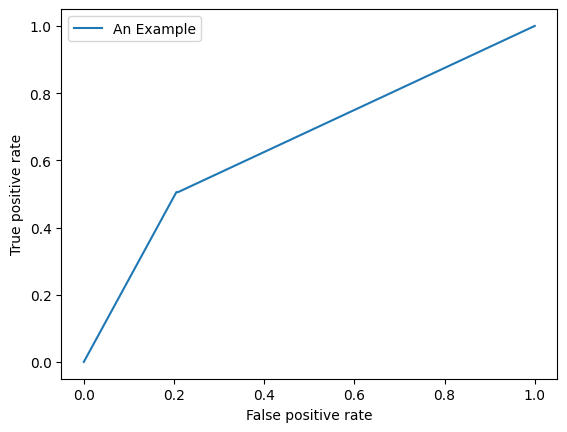

In [12]:
# The code below is just meant as an example for you to plot the ROC curve.
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

# Remember to use the training data here!!
example_model.fit(X_train, y_train)
# And to use the test data here!!
probs = example_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, probs)
plt.plot(fpr, tpr, label="An Example")
plt.ylabel("True positive rate")
plt.xlabel("False positive rate")
plt.legend()
plt.show()

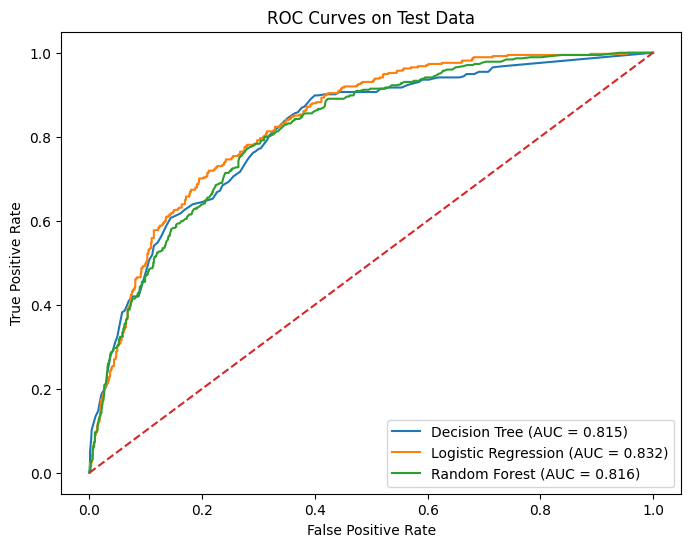

,model,test_auc
0,Logistic Regression,0.832310
1,Random Forest,0.815626
2,Decision Tree,0.814989


In [13]:
# Your code goes here
from sklearn.metrics import roc_curve, roc_auc_score
# 1. Get predicted probabilities for the positive class (churn = 1)
tree_probs = best_tree_model.predict_proba(X_test)[:, 1]
logit_probs = best_logit_model.predict_proba(X_test)[:, 1]
rf_probs = best_rf_model.predict_proba(X_test)[:, 1]

# 2. Compute ROC curve points
tree_fpr, tree_tpr, _ = roc_curve(y_test, tree_probs)
logit_fpr, logit_tpr, _ = roc_curve(y_test, logit_probs)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)

# 3. Compute test ROC AUC
tree_test_auc = roc_auc_score(y_test, tree_probs)
logit_test_auc = roc_auc_score(y_test, logit_probs)
rf_test_auc = roc_auc_score(y_test, rf_probs)

# 4. Plot the ROC curves
plt.figure(figsize=(8, 6))

plt.plot(tree_fpr, tree_tpr, label=f"Decision Tree (AUC = {tree_test_auc:.3f})")
plt.plot(logit_fpr, logit_tpr, label=f"Logistic Regression (AUC = {logit_test_auc:.3f})")
plt.plot(rf_fpr, rf_tpr, label=f"Random Forest (AUC = {rf_test_auc:.3f})")

# Random guessing line
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves on Test Data")
plt.legend(loc="lower right")
plt.show()

# 5. Put results in a table
test_auc_results = pd.DataFrame({
    "model": ["Decision Tree", "Logistic Regression", "Random Forest"],
    "test_auc": [tree_test_auc, logit_test_auc, rf_test_auc]
}).sort_values("test_auc", ascending=False).reset_index(drop=True)

test_auc_results

I won't change my mind. Logistic regression still has the highest ROC AUC on the test set (0.832)

__5. What would be the potential benefit of stopping someone from leaving? HINT: Take a look at the descriptions of the data and the retention offer.__

Put your answer here using Markdown.
If TelCo successfully stops a customer from churning, the company keeps that customer for one more year. Since the offer guarantees an extra year of contract, the benefit can be approximated by one year of revenue, or 12 × MonthlyCharges. Because the offer costs $200, the net benefit would be about 12 × MonthlyCharges - 200. This also means some customers are more valuable to retain than others, especially those with higher monthly charges.

__6. Split your training data into two sets, one with 90% of the data (the "sub-training" set) and another with 10% of the data (the validation set). Train the model you selected with the "sub-training" set, apply it to the validation set, and plot a profit curve by ranking customers according to their probability of churning. You will want to apply this models to customers that are not in the labeled data; make a recommendation of which customers to target with the retention incentive according to this profit curve.__

Best number of customers to target: 137
Best percent of validation customers to target: 24.33 %
Best cumulative profit on validation set: $ 50071.4
Probability threshold at this point: 0.4589


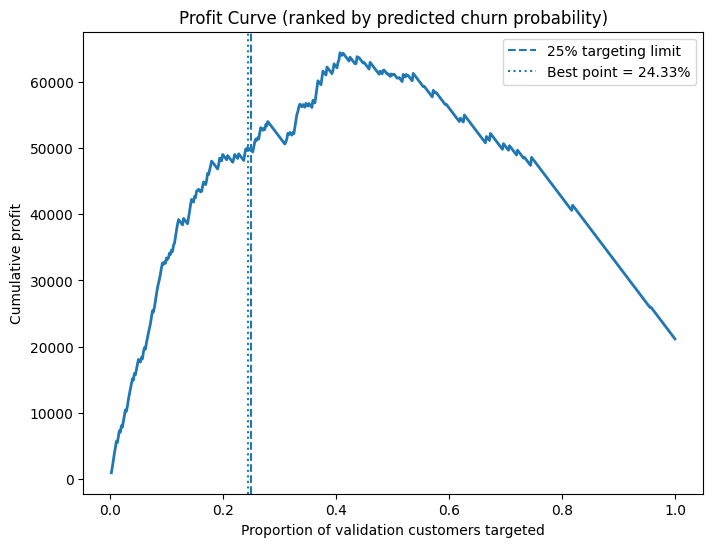

,SeniorCitizen,tenure,MonthlyCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,...,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,actual_churn,churn_prob,profit_if_targeted,num_targeted,pct_targeted,cumulative_profit
0,1,6,98.25,False,False,False,True,False,True,True,...,True,False,True,False,True,0.854652,979.0,1,0.001776,979.0
1,1,1,85.70,False,False,False,True,False,True,True,...,True,False,True,False,True,0.833217,828.4,2,0.003552,1807.4
2,1,8,105.50,False,False,False,True,False,True,True,...,True,False,True,False,True,0.831574,1066.0,3,0.005329,2873.4
3,1,16,98.75,True,True,False,True,False,True,True,...,True,False,True,False,True,0.830340,985.0,4,0.007105,3858.4
4,1,5,89.50,True,False,False,True,False,False,True,...,True,False,True,False,True,0.814899,874.0,5,0.008881,4732.4
5,0,11,99.50,False,True,False,True,False,True,True,...,True,False,True,False,True,0.810239,994.0,6,0.010657,5726.4
6,0,1,84.60,False,False,False,True,False,True,True,...,True,False,True,False,False,0.809779,-200.0,7,0.012433,5526.4
7,1,3,91.05,True,False,False,True,False,True,True,...,False,False,True,False,True,0.788087,892.6,8,0.014210,6419.0
8,0,7,90.45,True,False,False,True,False,True,True,...,True,False,True,False,True,0.776335,885.4,9,0.015986,7304.4
9,0,11,89.20,False,False,False,True,False,True,True,...,True,False,True,False,False,0.775210,-200.0,10,0.017762,7104.4


In [ ]:
# Your code goes here
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
%matplotlib inline

# Split the original training set into sub-training and validation
X_subtrain, X_val, y_subtrain, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.10,
    random_state=42,
    stratify=y_train
)

# Train the selected model (Logistic Regression) on the sub-training set
q6_model = LogisticRegression(
    C=best_logit_C,
    max_iter=1000,
    random_state=42
)

q6_model.fit(X_subtrain, y_subtrain)

# Predict churn probabilities on the validation set
val_probs = q6_model.predict_proba(X_val)[:, 1]

# Build a validation results table
profit_df = X_val.copy()
profit_df["actual_churn"] = y_val.values
profit_df["churn_prob"] = val_probs

#  Compute profit if targeted
"""
If the customer would churn and gets targeted:
    profit = 12 * MonthlyCharges - 200
 If the customer would not churn and gets targeted:
    profit = -200
"""
profit_df["profit_if_targeted"] = np.where(
    profit_df["actual_churn"] == 1,
    12 * profit_df["MonthlyCharges"] - 200,
    -200
)

#  Rank customers by predicted churn probability (highest first)
profit_df = profit_df.sort_values("churn_prob", ascending=False).reset_index(drop=True)

#  Compute cumulative profit curve
profit_df["num_targeted"] = np.arange(1, len(profit_df) + 1)
profit_df["pct_targeted"] = profit_df["num_targeted"] / len(profit_df)
profit_df["cumulative_profit"] = profit_df["profit_if_targeted"].cumsum()

#  Restrict attention to the top 25% because of the business constraint
max_targetable = int(np.floor(0.25 * len(profit_df)))
profit_df_25 = profit_df.iloc[:max_targetable].copy()

#  Find the best targeting point within the top 25%
best_idx = profit_df_25["cumulative_profit"].idxmax()
best_row = profit_df.loc[best_idx]

best_num_targeted = int(best_row["num_targeted"])
best_pct_targeted = best_row["pct_targeted"]
best_cum_profit = best_row["cumulative_profit"]
best_prob_threshold = best_row["churn_prob"]

print("Best number of customers to target:", best_num_targeted)
print("Best percent of validation customers to target:", round(best_pct_targeted * 100, 2), "%")
print("Best cumulative profit on validation set: $", round(best_cum_profit, 2))
print("Probability threshold at this point:", round(best_prob_threshold, 4))

#  Plot the profit curve
plt.figure(figsize=(8, 6))
plt.plot(profit_df["pct_targeted"], profit_df["cumulative_profit"], linewidth=2)
plt.axvline(x=0.25, linestyle="--", label="25% targeting limit")
plt.axvline(x=best_pct_targeted, linestyle=":", label=f"Best point = {best_pct_targeted:.2%}")
plt.xlabel("Proportion of validation customers targeted")
plt.ylabel("Cumulative profit")
plt.title("Profit Curve (ranked by predicted churn probability)")
plt.legend()
plt.show()

#  Show the top rows to inspect the ranking
profit_df.head(10)

I ranked validation customers by predicted churn probability and computed the cumulative profit from targeting the top customers in that order. Under the 25% targeting limit, the best point is to target 137 customers, or about 24.33% of the validation set. At this point, the cumulative profit is about $50,071.40, and the corresponding churn probability threshold is 0.4589. Therefore, I would recommend targeting customers with predicted churn probability at or above 0.4589.

__7. Can you think of something better than ranking according to the probability of churning? If so, tell us what it is and plot a profit curve according to this new ranking. Compare the results of the new ranking with the results you got in the previous question. Are the results any better? Would your recommendation change?__

Best number of customers to target: 140
Best percent of validation customers to target: 24.87 %
Best cumulative profit on validation set: $ 55542.8
Expected-profit score threshold at this point: 189.3341


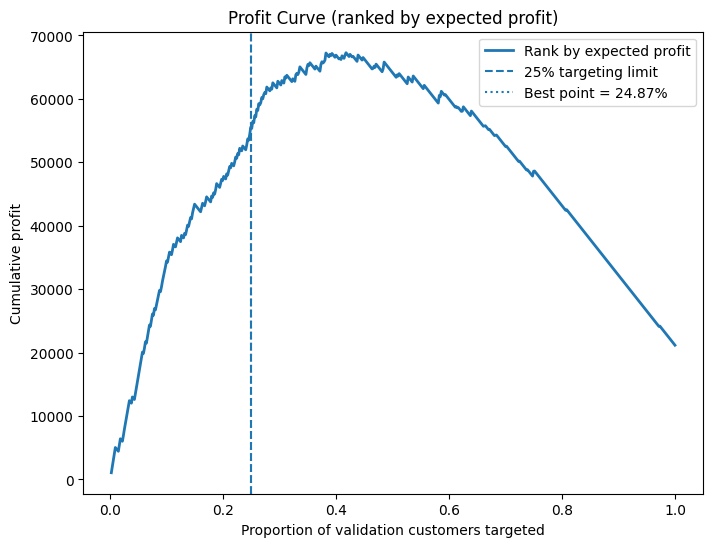

In [16]:
# Your code goes here

q7_df = X_val.copy()
q7_df["actual_churn"] = y_val.values
q7_df["churn_prob"] = val_probs

# Actual realized profit if targeted
q7_df["profit_if_targeted"] = np.where(
    q7_df["actual_churn"] == 1,
    12 * q7_df["MonthlyCharges"] - 200,
    -200
)

# New ranking score: expected profit of targeting
q7_df["expected_profit_score"] = 12 * q7_df["MonthlyCharges"] * q7_df["churn_prob"] - 200

# Rank by expected profit instead of churn probability
q7_df = q7_df.sort_values("expected_profit_score", ascending=False).reset_index(drop=True)

# Compute cumulative realized profit under this new ranking
q7_df["num_targeted"] = np.arange(1, len(q7_df) + 1)
q7_df["pct_targeted"] = q7_df["num_targeted"] / len(q7_df)
q7_df["cumulative_profit"] = q7_df["profit_if_targeted"].cumsum()

# Restrict to top 25%
max_targetable_q7 = int(np.floor(0.25 * len(q7_df)))
q7_df_25 = q7_df.iloc[:max_targetable_q7].copy()

# Best point within the 25% limit
best_idx_q7 = q7_df_25["cumulative_profit"].idxmax()
best_row_q7 = q7_df.loc[best_idx_q7]

best_num_targeted_q7 = int(best_row_q7["num_targeted"])
best_pct_targeted_q7 = best_row_q7["pct_targeted"]
best_cum_profit_q7 = best_row_q7["cumulative_profit"]
best_score_threshold_q7 = best_row_q7["expected_profit_score"]

print("Best number of customers to target:", best_num_targeted_q7)
print("Best percent of validation customers to target:", round(best_pct_targeted_q7 * 100, 2), "%")
print("Best cumulative profit on validation set: $", round(best_cum_profit_q7, 2))
print("Expected-profit score threshold at this point:", round(best_score_threshold_q7, 4))

# Plot the new profit curve
plt.figure(figsize=(8, 6))
plt.plot(q7_df["pct_targeted"], q7_df["cumulative_profit"], linewidth=2, label="Rank by expected profit")
plt.axvline(x=0.25, linestyle="--", label="25% targeting limit")
plt.axvline(x=best_pct_targeted_q7, linestyle=":", label=f"Best point = {best_pct_targeted_q7:.2%}")
plt.xlabel("Proportion of validation customers targeted")
plt.ylabel("Cumulative profit")
plt.title("Profit Curve (ranked by expected profit)")
plt.legend()
plt.show()

Yes, I found a better ranking method than sorting only by predicted churn probability. I ranked customers by expected profit, using 12 × MonthlyCharges × predicted churn probability - 200 as the score. This method gives a higher best cumulative profit on the validation set: about $55,542.80, compared with about $50,071.40 when ranking by churn probability alone. So I would recommend using expected profit as the ranking rule, since it accounts for both churn risk and customer value.

__8. Now the you have chosen a model and a threshold, it is time to evaluate the potential impact of your solution. Use the entire training data to train the model you selected, and then use the trained model on the test data to decide which customers to target with a retention offer. How much money do you estimate that your recommendation would have saved if we had given the retention offer to the customers in the test data?__

In [17]:
# Your code goes here

final_model = LogisticRegression(
    C=best_logit_C,   # this from Question 3
    max_iter=1000,
    random_state=42
)

final_model.fit(X_train, y_train)

# Predict churn probabilities on the test set
test_probs = final_model.predict_proba(X_test)[:, 1]

#  Build test results table
q8_df = X_test.copy()
q8_df["actual_churn"] = y_test.values
q8_df["churn_prob"] = test_probs

#  Compute expected profit score
# expected profit = 12 * MonthlyCharges * predicted_churn_probability - 200
q8_df["expected_profit_score"] = 12 * q8_df["MonthlyCharges"] * q8_df["churn_prob"] - 200

#   threshold chosen in Question 7
q7_threshold = 189.3341

q8_df["target"] = q8_df["expected_profit_score"] >= q7_threshold

# Enforce the 25% cap just in case
max_targetable_test = int(np.floor(0.25 * len(q8_df)))

if q8_df["target"].sum() > max_targetable_test:
    q8_df = q8_df.sort_values("expected_profit_score", ascending=False).reset_index(drop=True)
    q8_df["target"] = False
    q8_df.loc[:max_targetable_test - 1, "target"] = True

# 7. Compute realized profit on the test set
"""
 If targeted and actual churn = 1: profit = 12 * MonthlyCharges - 200
If targeted and actual churn = 0: profit = -200
If not targeted: profit = 0
"""
q8_df["realized_profit"] = np.where(
    q8_df["target"] & (q8_df["actual_churn"] == 1),
    12 * q8_df["MonthlyCharges"] - 200,
    np.where(
        q8_df["target"] & (q8_df["actual_churn"] == 0),
        -200,
        0
    )
)

# Summarize results
num_targeted_test = int(q8_df["target"].sum())
pct_targeted_test = num_targeted_test / len(q8_df)
total_profit_test = q8_df["realized_profit"].sum()

num_saved_customers = int(((q8_df["target"] == True) & (q8_df["actual_churn"] == 1)).sum())
avg_profit_per_targeted = total_profit_test / num_targeted_test if num_targeted_test > 0 else 0

print("Number of customers targeted:", num_targeted_test)
print("Percent of test customers targeted:", round(pct_targeted_test * 100, 2), "%")
print("Number of churners successfully retained:", num_saved_customers)
print("Total realized profit on test set: $", round(total_profit_test, 2))
print("Average profit per targeted customer: $", round(avg_profit_per_targeted, 2))

#  show targeted customers at the top
q8_df = q8_df.sort_values("expected_profit_score", ascending=False).reset_index(drop=True)
q8_df.head(15)

Number of customers targeted: 351
Percent of test customers targeted: 24.95 %
Number of churners successfully retained: 213
Total realized profit on test set: $ 146766.0
Average profit per targeted customer: $ 418.14


,SeniorCitizen,tenure,MonthlyCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,...,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,actual_churn,churn_prob,expected_profit_score,target,realized_profit
0,1,7,99.25,True,True,False,True,False,True,True,...,False,True,False,True,False,True,0.854717,817.968259,True,991.0
1,0,6,105.30,False,True,False,True,False,True,True,...,False,True,False,True,False,True,0.803079,814.770907,True,1063.6
2,0,3,100.95,True,False,False,True,False,True,True,...,False,True,False,True,False,True,0.834895,811.391597,True,1011.4
3,1,14,104.85,False,False,False,True,False,True,True,...,False,True,False,True,False,True,0.801959,809.024846,True,1058.2
4,1,1,95.10,True,True,False,True,False,True,True,...,False,True,False,True,False,True,0.865058,787.203633,True,941.2
5,1,3,94.85,True,False,False,True,False,True,True,...,False,True,False,True,False,False,0.863100,782.379896,True,-200.0
6,0,11,100.75,False,False,False,True,False,True,True,...,False,True,False,True,False,True,0.800852,768.230198,True,1009.0
7,0,12,106.70,True,False,False,True,False,True,True,...,False,True,False,True,False,True,0.754126,765.582900,True,1080.4
8,0,1,102.45,False,True,True,True,False,True,True,...,False,True,False,True,False,True,0.782187,761.620543,True,1029.4
9,1,21,104.35,True,False,False,True,False,True,True,...,False,True,False,True,False,False,0.765954,759.127718,True,-200.0


I retrained the final logistic regression model on the full training set and applied it to the test set. Then I used the expected-profit threshold from Question 7 to choose which customers to target. It successfully retains 213 actual churners and generates a total realized profit of about $146,766.